In [1]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

1. Чтение и первичная обработка
Загрузить CSV файл sales.csv
Вывести первые 5 строк
Проверить наличие пропущенных значений
Получить основную статистику по числовым столбцам

In [2]:
cities = ['Москва', 'СПб', 'Екатеринбург', 'Новосибирск', 'Казань', 'Владивосток', 'Сочи']
categories = ['Электроника', 'Продукты', 'Одежда', 'Книги', 'Спорт', 'Красота',
              'Автотовары', 'Мебель', 'Игрушки', 'Зоотовары', 'Ювелирные изделия', 'Строительные материалы']
n_rows = 200
dates = pd.date_range('2023-01-01', '2023-07-20', periods=n_rows)

data = []
for i in range(n_rows):
    city = np.random.choice(cities)
    category = np.random.choice(categories)
    quantity = np.random.randint(1, 10)
    price = np.random.randint(500, 5000)
    sales = quantity * price

    if np.random.random() < 0.1:
        city = np.nan
    if np.random.random() < 0.1:
        category = np.nan
    if np.random.random() < 0.1:
        quantity = np.nan
    if np.random.random() < 0.1:
        price = np.nan
    if np.random.random() < 0.1:
        sales = np.nan

    data.append({
        'date': dates[i].strftime('%Y-%m-%d'),
        'city': city,
        'category': category,
        'product_id': np.random.randint(1000, 2000),
        'sales': sales,
        'quantity': quantity,
        'price': price
    })

df = pd.DataFrame(data)

mask = df[['quantity', 'price', 'sales']].notna().all(axis=1)
df_valid = df[mask]
print(f"Проверка совпадения sales = quantity * price: {(df_valid['sales'] == df_valid['quantity'] * df_valid['price']).all()}")

df.to_csv('sales.csv', index=False, encoding='utf-8')

Проверка совпадения sales = quantity * price: True


In [3]:
df = pd.read_csv('sales.csv')

In [4]:
 df.head()

,date,city,category,product_id,sales,quantity,price
0,2023-01-01,NaN,Электроника,1578,2117.0,1.0,2117.0
1,2023-01-02,СПб,Игрушки,1608,16730.0,7.0,2390.0
2,2023-01-03,Екатеринбург,Автотовары,1620,14360.0,8.0,1795.0
3,2023-01-04,Новосибирск,Зоотовары,1845,24525.0,5.0,4905.0
4,2023-01-05,Владивосток,Мебель,1911,8811.0,3.0,2937.0


In [5]:
df.isna().mean()

,0
date,0.000
city,0.095
category,0.105
product_id,0.000
sales,0.115
quantity,0.085
price,0.100


In [6]:
df.describe()

,product_id,sales,quantity,price
count,200.000000,177.000000,183.000000,180.000000
mean,1501.500000,13288.672316,5.185792,2689.205556
std,283.588119,9359.412109,2.618282,1226.892121
min,1009.000000,741.000000,1.000000,520.000000
25%,1264.500000,5551.000000,3.000000,1580.500000
50%,1500.500000,11137.000000,5.000000,2753.500000
75%,1712.000000,19005.000000,7.000000,3734.250000
max,1998.000000,40185.000000,9.000000,4992.000000


2. Фильтрация данных
Выбрать строки, где продажи больше 1000
Найти записи за определенный период
Отфильтровать по нескольким условиям

In [7]:
df[df['sales']>1000]

,date,city,category,product_id,sales,quantity,price
0,2023-01-01,NaN,Электроника,1578,2117.0,1.0,2117.0
1,2023-01-02,СПб,Игрушки,1608,16730.0,7.0,2390.0
2,2023-01-03,Екатеринбург,Автотовары,1620,14360.0,8.0,1795.0
3,2023-01-04,Новосибирск,Зоотовары,1845,24525.0,5.0,4905.0
4,2023-01-05,Владивосток,Мебель,1911,8811.0,3.0,2937.0
...,...,...,...,...,...,...,...
193,2023-07-13,Екатеринбург,Одежда,1872,34947.0,9.0,3883.0
194,2023-07-14,Владивосток,Строительные материалы,1183,8676.0,6.0,1446.0
195,2023-07-15,Новосибирск,Электроника,1859,11600.0,4.0,2900.0
196,2023-07-16,Владивосток,Красота,1884,21777.0,7.0,3111.0


In [8]:
df[df['date']=='2023-04-10']

,date,city,category,product_id,sales,quantity,price
99,2023-04-10,Казань,Автотовары,1672,8928.0,6.0,NaN


In [9]:
df[(df['date']>='2023-01-01') & (df['date']<='2023-01-02') & (df['price']>2000)]

,date,city,category,product_id,sales,quantity,price
0,2023-01-01,NaN,Электроника,1578,2117.0,1.0,2117.0
1,2023-01-02,СПб,Игрушки,1608,16730.0,7.0,2390.0


3. Группировка данных
Посчитать суммарные продажи по городам
Найти средний чек по категориям товаров
Определить топ-5 по объему покупок

In [10]:
df.groupby(['city'])['sales'].sum().reset_index()

,city,sales
0,Владивосток,272372.0
1,Екатеринбург,321573.0
2,Казань,314376.0
3,Москва,273330.0
4,Новосибирск,361439.0
5,СПб,324291.0
6,Сочи,283494.0


In [11]:
(
    df.groupby('category')['sales']
    .mean()
    .reset_index()
    .sort_values(ascending=False, by='sales')
    )

,category,sales
3,Книги,18618.769231
5,Мебель,16115.466667
2,Игрушки,15350.090909
1,Зоотовары,15232.571429
4,Красота,14153.777778
11,Ювелирные изделия,13768.571429
8,Спорт,13345.933333
0,Автотовары,12697.928571
9,Строительные материалы,12297.470588
7,Продукты,12255.777778


In [12]:
(
    df.groupby('category')['quantity']
    .sum()
    .reset_index()
    .sort_values(ascending=False, by='quantity')
    ).head(5)

,category,quantity
5,Мебель,105.0
8,Спорт,103.0
9,Строительные материалы,100.0
1,Зоотовары,71.0
10,Электроника,71.0


4. Работа с NaN
Заполнить пропуски средним значением
Удалить строки с пропущенными данными
Создать новый столбец на основе существующих

In [13]:
numeric_columns = ['sales', 'quantity', 'price', 'product_id']
for col in numeric_columns:
    if df[col].isnull().any():
        mean_value = df[col].mean()
        df[col] = df[col].fillna(mean_value)
        print(f"Заполнены пропуски в столбце '{col}' средним значением: {mean_value:.2f}")

Заполнены пропуски в столбце 'sales' средним значением: 13288.67
Заполнены пропуски в столбце 'quantity' средним значением: 5.19
Заполнены пропуски в столбце 'price' средним значением: 2689.21


In [14]:
df.head()

,date,city,category,product_id,sales,quantity,price
0,2023-01-01,NaN,Электроника,1578,2117.0,1.0,2117.0
1,2023-01-02,СПб,Игрушки,1608,16730.0,7.0,2390.0
2,2023-01-03,Екатеринбург,Автотовары,1620,14360.0,8.0,1795.0
3,2023-01-04,Новосибирск,Зоотовары,1845,24525.0,5.0,4905.0
4,2023-01-05,Владивосток,Мебель,1911,8811.0,3.0,2937.0


In [15]:
df_clean = df.dropna()

In [16]:
df['error_checking'] = df['quantity']*price == df['sales']

In [17]:
df.head()

,date,city,category,product_id,sales,quantity,price,error_checking
0,2023-01-01,NaN,Электроника,1578,2117.0,1.0,2117.0,False
1,2023-01-02,СПб,Игрушки,1608,16730.0,7.0,2390.0,False
2,2023-01-03,Екатеринбург,Автотовары,1620,14360.0,8.0,1795.0,False
3,2023-01-04,Новосибирск,Зоотовары,1845,24525.0,5.0,4905.0,False
4,2023-01-05,Владивосток,Мебель,1911,8811.0,3.0,2937.0,False


5. Работа с временными рядами

In [18]:
df['date'] = pd.to_datetime(df['date'])

In [19]:
df['year_month'] = df['date'].dt.strftime('%Y-%m')


In [20]:
df.head()

,date,city,category,product_id,sales,quantity,price,error_checking,year_month
0,2023-01-01,NaN,Электроника,1578,2117.0,1.0,2117.0,False,2023-01
1,2023-01-02,СПб,Игрушки,1608,16730.0,7.0,2390.0,False,2023-01
2,2023-01-03,Екатеринбург,Автотовары,1620,14360.0,8.0,1795.0,False,2023-01
3,2023-01-04,Новосибирск,Зоотовары,1845,24525.0,5.0,4905.0,False,2023-01
4,2023-01-05,Владивосток,Мебель,1911,8811.0,3.0,2937.0,False,2023-01


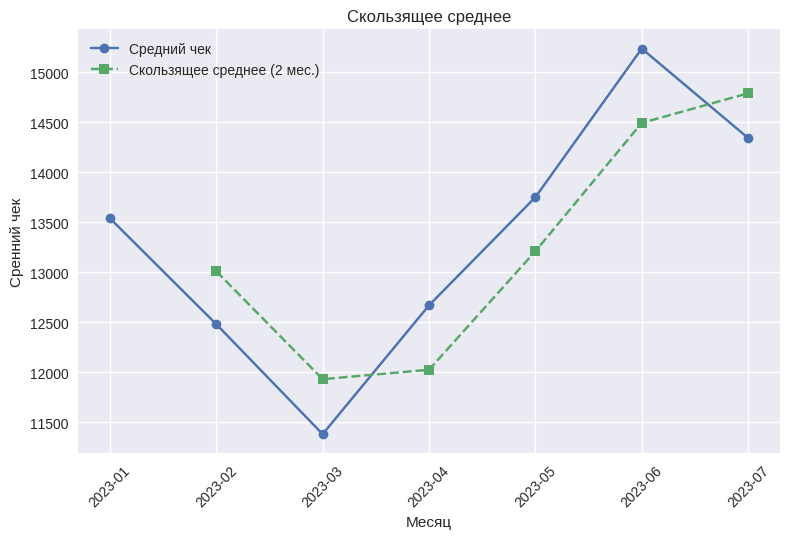

In [21]:
monthly_sales = df.groupby('year_month')['sales'].mean()

rolling_mean = monthly_sales.rolling(window=2).mean()

plt.plot(monthly_sales.index, monthly_sales, marker='o', label='Средний чек')
plt.plot(rolling_mean.index, rolling_mean, marker='s', linestyle='--', label='Скользящее среднее (2 мес.)')
plt.xticks(rotation=45)
plt.xlabel('Месяц')
plt.ylabel('Сренний чек')
plt.title('Скользящее среднее')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [22]:
df['quarter'] = df['date'].dt.quarter
df['year_quarter'] = df['date'].dt.year.astype(str) + '-Q' + df['date'].dt.quarter.astype(str)

quarterly_total = df.groupby('year_quarter').agg({
    'sales': ['sum', 'mean', 'count'],
    'quantity': 'sum',
    'price': 'mean'
}).round(2)

In [23]:
quarterly_total

sales                quantity    price
                     sum     mean count      sum     mean
year_quarter                                             
2023-Q1       1121877.38  12465.3    90   451.93  2680.85
2023-Q2       1263353.40  13883.0    91   489.04  2665.65
2023-Q3        272503.69  14342.3    19    96.19  2841.64

In [24]:
df_gr = df.groupby('year_month')['sales'].sum().reset_index()

In [25]:
df_gr

,year_month,sales
0,2023-01,419687.361582
1,2023-02,349417.016949
2,2023-03,352773.000000
3,2023-04,380040.344633
4,2023-05,426233.033898
5,2023-06,457080.016949
6,2023-07,272503.689266


6. Визуализация данных

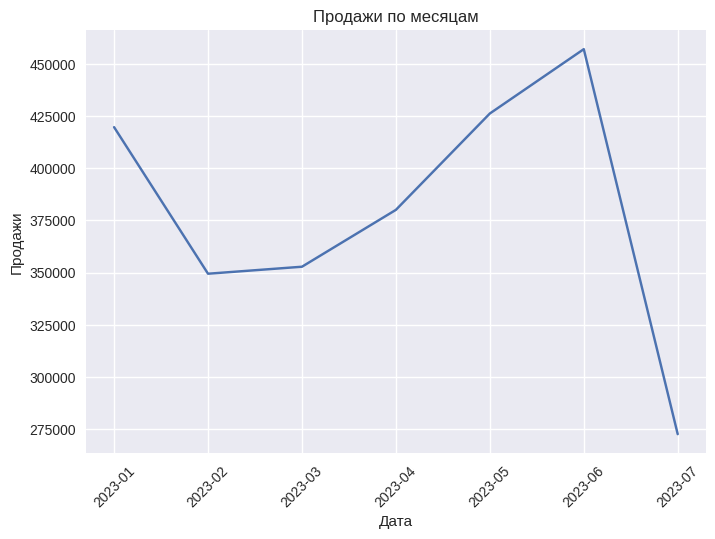

In [26]:

plt.plot(df_gr['year_month'], df_gr['sales'])
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.title('Продажи по месяцам')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

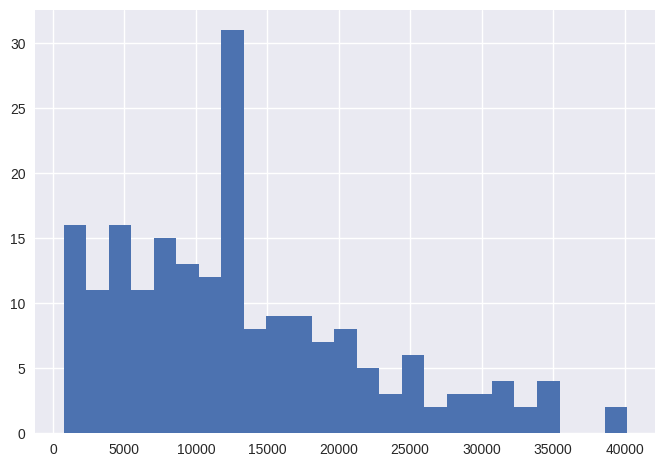

In [27]:
df['sales'].hist(bins=25);

In [28]:
df_grouped = df.groupby('date')['sales'].sum().reset_index()

In [29]:
df_grouped['sales_lag'] = df_grouped['sales'].shift(1)

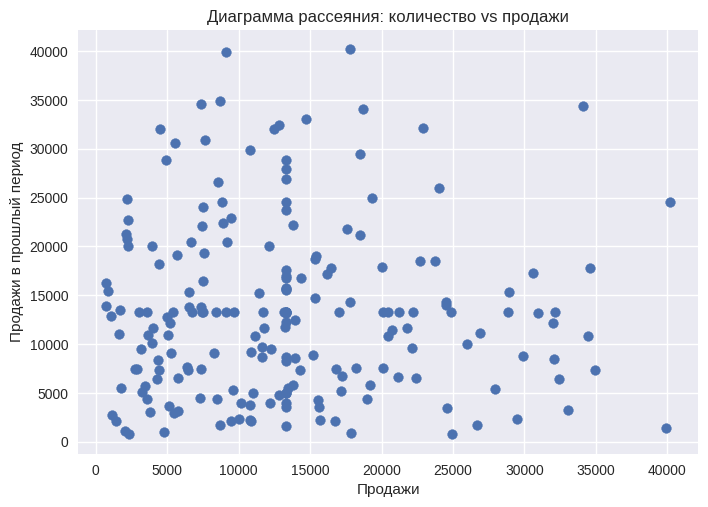

In [30]:
plt.scatter(df_grouped['sales'], df_grouped['sales_lag'])
plt.xlabel('Продажи')
plt.ylabel('Продажи в прошлый период')
plt.title('Диаграмма рассеяния: количество vs продажи')
plt.grid(True)
plt.show()
